# Pandas 常见用法

覆盖下面这条数据处理链路：

```text
读取数据 → 检查数据 → 选择/筛选 → 清洗缺失值与重复值
→ 类型转换 → 类别编码 → 分组统计/合并 → 划分特征和标签
→ NumPy / PyTorch Tensor
```

## 目录

1. 创建 `Series` 与 `DataFrame`
2. 快速查看与理解数据
3. 行列选择：`[]`、`loc`、`iloc`、`at`、`iat`
4. 条件筛选、排序与抽样
5. 新增、修改、删除与重命名
6. 缺失值、重复值和异常数据
7. 数据类型、字符串与日期
8. 类别编码与特征工程
9. 分组、聚合、透视表与交叉表
10. 合并、拼接与长宽表转换
11. 相关性与简单可视化
12. CSV/Excel/Parquet 读写
13. 机器学习完整预处理流程
14. DataFrame → NumPy → Tensor
15. 常见错误与速查表
16. 综合练习

## 0. 导入库与显示设置

- `pandas`：表格数据处理。
- `numpy`：数值数组。
- `Path`：跨平台路径处理。
- 不建议通过大量全局显示设置“隐藏问题”；这里只适当扩大显示范围。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.2.3
NumPy version: 2.3.5


# 1. 创建 Series 与 DataFrame

- `Series`：一维、带索引的数据。
- `DataFrame`：二维表格；机器学习中通常 **一行是一条样本，一列是一个特征**。

In [2]:
# Series：一维数据
scores = pd.Series([85, 90, 78], index=["Tom", "Jerry", "Alice"], name="score")
scores

Tom      85
Jerry    90
Alice    78
Name: score, dtype: int64

In [3]:
# DataFrame：由字典创建二维表格
# 保留原练习中的主要字段，并补充 student_id、city、exam_date 便于演示更多常用操作。
data = {
    "student_id": [1001, 1002, 1003, 1004, 1005, 1006],
    "name": ["Tom", "Jerry", "Alice", "Bob", "Mike", "Lucy"],
    "gender": ["male", "male", "female", "male", "male", "female"],
    "city": ["Dalian", "Shenyang", "Dalian", "Beijing", "Shenyang", "Dalian"],
    "score": [85, 90, 78, 92, 66, 88],
    "study_hours": [5, 6, 3, 7, 2, 6],
    "exam_date": pd.to_datetime([
        "2026-07-01", "2026-07-01", "2026-07-01",
        "2026-07-02", "2026-07-02", "2026-07-02",
    ]),
}

df = pd.DataFrame(data)
df

,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
4,1005,Mike,male,Shenyang,66,2,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


# 2. 快速查看与理解数据

拿到陌生数据后，优先检查：

```text
前几行 → 行列数 → 列名 → 数据类型 → 缺失值 → 描述统计
```

In [4]:
print("前 3 行：")
display(df.head(3))

print("后 2 行：")
display(df.tail(2))

print("随机抽取 2 行：")
display(df.sample(n=2, random_state=42))

前 3 行：


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01


后 2 行：


,student_id,name,gender,city,score,study_hours,exam_date
4,1005,Mike,male,Shenyang,66,2,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


随机抽取 2 行：


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01


In [5]:
print("形状（行数, 列数）：", df.shape)
print("样本数：", len(df))
print("列名：", df.columns.tolist())
print("索引：", df.index.tolist())
print("各列类型：")
display(df.dtypes)

形状（行数, 列数）： (6, 7)
样本数： 6
列名： ['student_id', 'name', 'gender', 'city', 'score', 'study_hours', 'exam_date']
索引： [0, 1, 2, 3, 4, 5]
各列类型：


student_id              int64
name                   object
gender                 object
city                   object
score                   int64
study_hours             int64
exam_date      datetime64[ns]
dtype: object

In [6]:
# info()：类型、非空数量、内存占用，是数据检查中最重要的方法之一。
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   student_id   6 non-null      int64         
 1   name         6 non-null      object        
 2   gender       6 non-null      object        
 3   city         6 non-null      object        
 4   score        6 non-null      int64         
 5   study_hours  6 non-null      int64         
 6   exam_date    6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 468.0+ bytes


In [7]:
# 数值列描述统计：数量、均值、标准差、分位数、最大最小值。
df.describe()

,student_id,score,study_hours,exam_date
count,6.000000,6.000000,6.000000,6
mean,1003.500000,83.166667,4.833333,2026-07-01 12:00:00
min,1001.000000,66.000000,2.000000,2026-07-01 00:00:00
25%,1002.250000,79.750000,3.500000,2026-07-01 00:00:00
50%,1003.500000,86.500000,5.500000,2026-07-01 12:00:00
75%,1004.750000,89.500000,6.000000,2026-07-02 00:00:00
max,1006.000000,92.000000,7.000000,2026-07-02 00:00:00
std,1.870829,9.724539,1.940790,NaN


In [8]:
# include="all" 同时查看字符串、类别、日期等列。
df.describe(include="all")

,student_id,name,gender,city,score,study_hours,exam_date
count,6.000000,6,6,6,6.000000,6.000000,6
unique,NaN,6,2,3,NaN,NaN,NaN
top,NaN,Tom,male,Dalian,NaN,NaN,NaN
freq,NaN,1,4,3,NaN,NaN,NaN
mean,1003.500000,NaN,NaN,NaN,83.166667,4.833333,2026-07-01 12:00:00
min,1001.000000,NaN,NaN,NaN,66.000000,2.000000,2026-07-01 00:00:00
25%,1002.250000,NaN,NaN,NaN,79.750000,3.500000,2026-07-01 00:00:00
50%,1003.500000,NaN,NaN,NaN,86.500000,5.500000,2026-07-01 12:00:00
75%,1004.750000,NaN,NaN,NaN,89.500000,6.000000,2026-07-02 00:00:00
max,1006.000000,NaN,NaN,NaN,92.000000,7.000000,2026-07-02 00:00:00


## 高频检查方法

| 代码 | 作用 |
|---|---|
| `df.head()` / `df.tail()` | 查看开头/末尾 |
| `df.sample()` | 随机抽样 |
| `df.shape` | `(行数, 列数)` |
| `df.columns` / `df.index` | 列名 / 行索引 |
| `df.dtypes` | 每列数据类型 |
| `df.info()` | 非空数量、类型、内存 |
| `df.describe()` | 数值描述统计 |
| `df.nunique()` | 每列不同值数量 |
| `df.isna().sum()` | 每列缺失值数量 |

In [9]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})
summary

,dtype,non_null,missing,unique
student_id,int64,6,0,6
name,object,6,0,6
gender,object,6,0,2
city,object,6,0,3
score,int64,6,0,6
study_hours,int64,6,0,5
exam_date,datetime64[ns],6,0,2


# 3. 选择行和列

## 3.1 选择列

- `df["score"]` 返回 `Series`，形状通常是 `(n,)`。
- `df[["score"]]` 返回 `DataFrame`，形状通常是 `(n, 1)`。
- 多列必须使用双层方括号：`df[["score", "study_hours"]]`。

In [10]:
score_series = df["score"]
score_dataframe = df[["score"]]
selected_columns = df[["name", "score", "study_hours"]]

print(type(score_series), score_series.shape)
print(type(score_dataframe), score_dataframe.shape)
display(selected_columns)

<class 'pandas.core.series.Series'> (6,)
<class 'pandas.core.frame.DataFrame'> (6, 1)


,name,score,study_hours
0,Tom,85,5
1,Jerry,90,6
2,Alice,78,3
3,Bob,92,7
4,Mike,66,2
5,Lucy,88,6


## 3.2 `loc` 与 `iloc`

- `loc`：按 **索引标签/列名** 选择；标签切片的结束位置通常包含在内。
- `iloc`：按 **整数位置** 选择；规则和 Python 切片相同，右端不包含。
- Pandas 中没有 `.jloc[]`。

In [11]:
# loc：按标签。默认索引是 0,1,2,...，所以 1:3 会包含标签 3。
display(df.loc[1:3, ["name", "score"]])

# iloc：按位置。1:4 表示第 2 到第 4 行，不包含位置 4。
display(df.iloc[1:4, [1, 4]])

,name,score
1,Jerry,90
2,Alice,78
3,Bob,92


,name,score
1,Jerry,90
2,Alice,78
3,Bob,92


In [12]:
# 设置 name 为索引后，loc 的“按标签”特性更直观。
df_by_name = df.set_index("name")

print("按标签取 Alice：")
display(df_by_name.loc["Alice"])

print("按位置取第 3 行：")
display(df_by_name.iloc[2])

按标签取 Alice：


student_id                    1003
gender                      female
city                        Dalian
score                           78
study_hours                      3
exam_date      2026-07-01 00:00:00
Name: Alice, dtype: object

按位置取第 3 行：


student_id                    1003
gender                      female
city                        Dalian
score                           78
study_hours                      3
exam_date      2026-07-01 00:00:00
Name: Alice, dtype: object

## 3.3 `df[:n]` 和 `df.iloc[:n]`

在普通 DataFrame 中，两者通常都表示取前 `n` 行：

```python
df[:n]
df.iloc[:n]
```

但 `.iloc` 明确表达“按整数位置取行”，可读性更好，因此在拆分训练集/测试集时更推荐：

```python
train_part = all_features.iloc[:n_train]
test_part = all_features.iloc[n_train:]
```

In [13]:
n = 3
print("df[:n]：")
display(df[:n])

print("df.iloc[:n]：")
display(df.iloc[:n])

df[:n]：


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01


df.iloc[:n]：


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01


## 3.4 `at` 与 `iat`

只读取或修改 **单个元素** 时：

- `at[行标签, 列名]`
- `iat[行位置, 列位置]`

In [14]:
print("df.at[0, 'name']：", df.at[0, "name"])
print("df.iat[0, 1]：", df.iat[0, 1])

df.at[0, 'name']： Tom
df.iat[0, 1]： Tom


# 4. 条件筛选、排序与抽样

Pandas 的条件筛选会先生成一个布尔掩码，再保留值为 `True` 的行。

注意：多个条件必须分别加括号，并使用：

- `&`：并且
- `|`：或者
- `~`：取反

不能直接使用 Python 的 `and`、`or`。

In [15]:
# 单条件筛选
high_score_students = df[df["score"] >= 85]
high_score_students

,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


In [16]:
# 多条件筛选
result = df[(df["score"] >= 85) & (df["study_hours"] >= 5)]
result

,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


In [17]:
# isin：属于某些类别
cities = df[df["city"].isin(["Dalian", "Beijing"])]

# between：位于闭区间内
score_range = df[df["score"].between(80, 90)]

# query：表达式可读性较好，列名简单时使用方便
query_result = df.query("score >= 85 and study_hours >= 5")

display(cities)
display(score_range)
display(query_result)

,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
5,1006,Lucy,female,Dalian,88,6,2026-07-02


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


In [18]:
# 排序：默认升序；ascending=False 表示降序。
df_sorted = df.sort_values(
    by=["score", "study_hours"],
    ascending=[False, False],
)
display(df_sorted)

# 直接取分数最高的 3 行。
display(df.nlargest(3, "score"))

,student_id,name,gender,city,score,study_hours,exam_date
3,1004,Bob,male,Beijing,92,7,2026-07-02
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
5,1006,Lucy,female,Dalian,88,6,2026-07-02
0,1001,Tom,male,Dalian,85,5,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01
4,1005,Mike,male,Shenyang,66,2,2026-07-02


,student_id,name,gender,city,score,study_hours,exam_date
3,1004,Bob,male,Beijing,92,7,2026-07-02
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
5,1006,Lucy,female,Dalian,88,6,2026-07-02


# 5. 新增、修改、删除与重命名

修改数据前，常用 `copy()` 创建副本，避免无意改变原表。

In [19]:
df_work = df.copy()

# 新增布尔列。
df_work["passed"] = df_work["score"] >= 60

# 由已有列计算新特征。
df_work["score_per_hour"] = df_work["score"] / df_work["study_hours"]

# 使用 loc 按条件修改，避免链式赋值问题。
df_work.loc[df_work["score"] >= 90, "level"] = "excellent"
df_work.loc[df_work["score"] < 90, "level"] = "normal"

df_work

,student_id,name,gender,city,score,study_hours,exam_date,passed,score_per_hour,level
0,1001,Tom,male,Dalian,85,5,2026-07-01,True,17.000000,normal
1,1002,Jerry,male,Shenyang,90,6,2026-07-01,True,15.000000,excellent
2,1003,Alice,female,Dalian,78,3,2026-07-01,True,26.000000,normal
3,1004,Bob,male,Beijing,92,7,2026-07-02,True,13.142857,excellent
4,1005,Mike,male,Shenyang,66,2,2026-07-02,True,33.000000,normal
5,1006,Lucy,female,Dalian,88,6,2026-07-02,True,14.666667,normal


In [20]:
# rename：重命名列。
df_renamed = df_work.rename(columns={"study_hours": "hours"})

# drop：删除列或行。axis=1 表示列；更推荐直接写 columns=。
df_dropped = df_renamed.drop(columns=["score_per_hour"])

# reset_index：重新生成 0,1,2,... 索引；drop=True 不保留旧索引。
df_reset = df_dropped.reset_index(drop=True)

df_reset.head()

,student_id,name,gender,city,score,hours,exam_date,passed,level
0,1001,Tom,male,Dalian,85,5,2026-07-01,True,normal
1,1002,Jerry,male,Shenyang,90,6,2026-07-01,True,excellent
2,1003,Alice,female,Dalian,78,3,2026-07-01,True,normal
3,1004,Bob,male,Beijing,92,7,2026-07-02,True,excellent
4,1005,Mike,male,Shenyang,66,2,2026-07-02,True,normal


## `axis` 的记忆方法

- `axis=0`：沿行方向操作，通常意味着“处理每一列”或“删除行”。
- `axis=1`：沿列方向操作，通常意味着“处理每一行”或“删除列”。

优先使用语义更明确的参数：

```python
df.drop(columns=[...])
df.drop(index=[...])
```

# 6. 缺失值、重复值和异常数据

机器学习前必须检查：

```python
df.isna().sum()
df.duplicated().sum()
```

缺失值处理没有统一答案，常见方式包括删除、均值/中位数/众数填充、插值或交给模型/预处理器处理。

In [21]:
data_with_missing = {
    "name": ["Tom", "Jerry", "Alice", "Bob", "Bob"],
    "gender": ["male", "male", "female", None, None],
    "score": [85, None, 78, 92, 92],
    "study_hours": [5, 6, None, 7, 7],
}

df_missing = pd.DataFrame(data_with_missing)
df_missing

,name,gender,score,study_hours
0,Tom,male,85.0,5.0
1,Jerry,male,NaN,6.0
2,Alice,female,78.0,NaN
3,Bob,None,92.0,7.0
4,Bob,None,92.0,7.0


In [22]:
print("缺失值位置：")
display(df_missing.isna())

print("每列缺失数量：")
display(df_missing.isna().sum())

print("每列缺失比例：")
display(df_missing.isna().mean())

缺失值位置：


,name,gender,score,study_hours
0,False,False,False,False
1,False,False,True,False
2,False,False,False,True
3,False,True,False,False
4,False,True,False,False


每列缺失数量：


name           0
gender         2
score          1
study_hours    1
dtype: int64

每列缺失比例：


name           0.0
gender         0.4
score          0.2
study_hours    0.2
dtype: float64

In [23]:
# 删除关键列缺失的行。
dropped_rows = df_missing.dropna(subset=["score"])

# 填充：数值列常用中位数；类别列常用众数或固定字符串。
df_filled = df_missing.copy()
df_filled["score"] = df_filled["score"].fillna(df_filled["score"].median())
df_filled["study_hours"] = df_filled["study_hours"].fillna(
    df_filled["study_hours"].median()
)
df_filled["gender"] = df_filled["gender"].fillna("unknown")

print("删除 score 缺失行：")
display(dropped_rows)
print("填充后：")
display(df_filled)

删除 score 缺失行：


,name,gender,score,study_hours
0,Tom,male,85.0,5.0
2,Alice,female,78.0,NaN
3,Bob,None,92.0,7.0
4,Bob,None,92.0,7.0


填充后：


,name,gender,score,study_hours
0,Tom,male,85.0,5.0
1,Jerry,male,88.5,6.0
2,Alice,female,78.0,6.5
3,Bob,unknown,92.0,7.0
4,Bob,unknown,92.0,7.0


> **机器学习中的关键原则：** 填充值必须只由训练集计算，再应用到验证集和测试集。若先使用全体数据计算均值/中位数，会产生数据泄漏。

In [24]:
# 重复值检查与删除。
print("完整重复行：")
display(df_missing[df_missing.duplicated(keep=False)])

print("按 name 判断重复：")
display(df_missing[df_missing.duplicated(subset=["name"], keep=False)])

unique_rows = df_missing.drop_duplicates()
unique_rows

完整重复行：


,name,gender,score,study_hours
3,Bob,None,92.0,7.0
4,Bob,None,92.0,7.0


按 name 判断重复：


,name,gender,score,study_hours
3,Bob,None,92.0,7.0
4,Bob,None,92.0,7.0


,name,gender,score,study_hours
0,Tom,male,85.0,5.0
1,Jerry,male,NaN,6.0
2,Alice,female,78.0,NaN
3,Bob,None,92.0,7.0


## 简单异常值筛选

业务规则通常比统一公式更可靠。例如分数应位于 `[0, 100]`：

In [25]:
df_abnormal = df.copy()
df_abnormal.loc[len(df_abnormal)] = [1007, "Error", "male", "Dalian", 150, 4, pd.Timestamp("2026-07-03")]

invalid_score = df_abnormal[~df_abnormal["score"].between(0, 100)]
invalid_score

,student_id,name,gender,city,score,study_hours,exam_date
6,1007,Error,male,Dalian,150,4,2026-07-03


# 7. 数据类型、字符串与日期

常见类型：

- 整数：`int64`
- 浮点数：`float64`
- 布尔值：`bool`
- 字符串/混合类型：`object` 或 `string`
- 类别：`category`
- 日期：`datetime64[ns]`

模型通常要求统一的数值类型，因此训练前要特别注意 `object` 列。

In [26]:
raw_types = pd.DataFrame({
    "age": ["18", "20", "unknown"],
    "city": [" Dalian ", "SHENYANG", "dalian"],
    "date": ["2026-07-01", "2026/07/02", "bad-date"],
})

# errors="coerce"：无法转换的值变为 NaN/NaT，便于后续统一处理。
raw_types["age_numeric"] = pd.to_numeric(raw_types["age"], errors="coerce")
raw_types["date_parsed"] = pd.to_datetime(raw_types["date"], errors="coerce")

# 字符串清洗：去空格、统一大小写。
raw_types["city_clean"] = raw_types["city"].str.strip().str.lower()

# 重复类别较少时，可转为 category 以节省内存。
raw_types["city_category"] = raw_types["city_clean"].astype("category")

raw_types

,age,city,date,age_numeric,date_parsed,city_clean,city_category
0,18,Dalian,2026-07-01,18.0,2026-07-01,dalian,dalian
1,20,SHENYANG,2026/07/02,20.0,NaT,shenyang,shenyang
2,unknown,dalian,bad-date,NaN,NaT,dalian,dalian


In [27]:
# 常见字符串操作。
print(raw_types["city_clean"].str.contains("dalian", na=False))
print(raw_types["city_clean"].str.replace("shenyang", "sy", regex=False))

# 常见日期特征提取。
print(raw_types["date_parsed"].dt.year)
print(raw_types["date_parsed"].dt.month)
print(raw_types["date_parsed"].dt.dayofweek)  # 周一为 0

0     True
1    False
2     True
Name: city_clean, dtype: bool
0    dalian
1        sy
2    dalian
Name: city_clean, dtype: object
0    2026.0
1       NaN
2       NaN
Name: date_parsed, dtype: float64
0    7.0
1    NaN
2    NaN
Name: date_parsed, dtype: float64
0    2.0
1    NaN
2    NaN
Name: date_parsed, dtype: float64


# 8. 类别编码与特征工程

神经网络和大多数传统机器学习模型不能直接处理 `"male"`、`"Dalian"` 等字符串。

常见方法：

1. 二分类映射：`map()`
2. 独热编码：`pd.get_dummies()`
3. 连续变量分箱：`pd.cut()` / `pd.qcut()`

In [28]:
# 二分类映射。
df_encoded = df.copy()
df_encoded["gender_code"] = df_encoded["gender"].map({"male": 0, "female": 1})

df_encoded[["gender", "gender_code"]]

,gender,gender_code
0,male,0
1,male,0
2,female,1
3,male,0
4,male,0
5,female,1


In [29]:
# One-Hot Encoding（独热编码）。
# dtype="int8" 让生成列使用更小的整数类型。
# dummy_na=True 会把缺失值单独编码成一列。
dummies = pd.get_dummies(
    df[["gender", "city"]],
    columns=["gender", "city"],
    dummy_na=True,
    dtype="int8",
)
dummies

,gender_female,gender_male,gender_nan,city_Beijing,city_Dalian,city_Shenyang,city_nan
0,0,1,0,0,1,0,0
1,0,1,0,0,0,1,0
2,1,0,0,0,1,0,0
3,0,1,0,1,0,0,0
4,0,1,0,0,0,1,0
5,1,0,0,0,1,0,0


In [30]:
# 分箱：把连续分数转成有序区间。
df_feature = df.copy()
df_feature["score_level"] = pd.cut(
    df_feature["score"],
    bins=[0, 70, 85, 100],
    labels=["low", "medium", "high"],
    include_lowest=True,
)

df_feature[["name", "score", "score_level"]]

,name,score,score_level
0,Tom,85,medium
1,Jerry,90,high
2,Alice,78,medium
3,Bob,92,high
4,Mike,66,low
5,Lucy,88,high


## `map`、`apply` 与向量化

优先级通常是：

```text
Pandas/NumPy 向量化运算 > map/apply > Python for 循环
```

- `Series.map()`：逐元素映射，适合字典编码。
- `Series.apply()`：逐元素调用自定义函数，灵活但通常比向量化慢。
- 能直接写 `df["a"] / df["b"]` 时，不要用逐行 `apply`。

In [31]:
def score_comment(score):
    return "good" if score >= 85 else "keep going"

comments = df["score"].apply(score_comment)
comments

0          good
1          good
2    keep going
3          good
4    keep going
5          good
Name: score, dtype: object

# 9. 分组、聚合、透视表与交叉表

In [32]:
# value_counts：类别频数，是最常用的快速统计之一。
print(df["gender"].value_counts())
print(df["city"].value_counts(normalize=True))  # 比例

gender
male      4
female    2
Name: count, dtype: int64
city
Dalian      0.500000
Shenyang    0.333333
Beijing     0.166667
Name: proportion, dtype: float64


In [33]:
# groupby：按 gender 分组，计算 score 均值。
gender_score_mean = df.groupby("gender")["score"].mean()
gender_score_mean

gender
female    83.00
male      83.25
Name: score, dtype: float64

In [34]:
# agg：一次计算多个统计量，并可为结果命名。
group_summary = (
    df.groupby("gender")
      .agg(
          student_count=("student_id", "count"),
          score_mean=("score", "mean"),
          score_max=("score", "max"),
          hours_mean=("study_hours", "mean"),
      )
      .reset_index()
)
group_summary

,gender,student_count,score_mean,score_max,hours_mean
0,female,2,83.00,88,4.5
1,male,4,83.25,92,5.0


In [35]:
# transform：返回与原 DataFrame 等长的结果，适合生成“组内特征”。
df_group_feature = df.copy()
df_group_feature["gender_score_mean"] = (
    df_group_feature.groupby("gender")["score"].transform("mean")
)
df_group_feature["score_minus_gender_mean"] = (
    df_group_feature["score"] - df_group_feature["gender_score_mean"]
)

df_group_feature[["name", "gender", "score", "gender_score_mean", "score_minus_gender_mean"]]

,name,gender,score,gender_score_mean,score_minus_gender_mean
0,Tom,male,85,83.25,1.75
1,Jerry,male,90,83.25,6.75
2,Alice,female,78,83.00,-5.00
3,Bob,male,92,83.25,8.75
4,Mike,male,66,83.25,-17.25
5,Lucy,female,88,83.00,5.00


In [36]:
# pivot_table：类似 Excel 数据透视表。
pivot = pd.pivot_table(
    df,
    index="city",
    columns="gender",
    values="score",
    aggfunc="mean",
    fill_value=0,
)
pivot

gender,female,male
city,,
Beijing,0.0,92.0
Dalian,83.0,85.0
Shenyang,0.0,78.0


In [37]:
# crosstab：交叉频数表。
pd.crosstab(df["city"], df["gender"], margins=True)

gender,female,male,All
city,,,
Beijing,0,1,1
Dalian,2,1,3
Shenyang,0,2,2
All,2,4,6


# 10. 合并、拼接与长宽表转换

- `merge`：按键连接，类似 SQL JOIN。
- `concat`：按行或按列直接拼接。
- `melt`：宽表转长表。
- `pivot` / `pivot_table`：长表转宽表。

In [38]:
extra = pd.DataFrame({
    "student_id": [1001, 1002, 1003, 1006],
    "club": ["AI", "Math", "Art", "AI"],
})

# 左连接：保留 df 中所有学生，匹配不到的 club 为 NaN。
merged = df.merge(extra, on="student_id", how="left", validate="one_to_one")
merged

,student_id,name,gender,city,score,study_hours,exam_date,club
0,1001,Tom,male,Dalian,85,5,2026-07-01,AI
1,1002,Jerry,male,Shenyang,90,6,2026-07-01,Math
2,1003,Alice,female,Dalian,78,3,2026-07-01,Art
3,1004,Bob,male,Beijing,92,7,2026-07-02,NaN
4,1005,Mike,male,Shenyang,66,2,2026-07-02,NaN
5,1006,Lucy,female,Dalian,88,6,2026-07-02,AI


In [39]:
# concat：按行拼接时常配合 ignore_index=True 重建索引。
part1 = df.iloc[:3]
part2 = df.iloc[3:]
combined_rows = pd.concat([part1, part2], axis=0, ignore_index=True)

# 按列拼接时 axis=1；Pandas 会按照索引对齐。
combined_columns = pd.concat(
    [df[["name", "score"]], df[["study_hours"]]],
    axis=1,
)

display(combined_rows)
display(combined_columns)

,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
4,1005,Mike,male,Shenyang,66,2,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


,name,score,study_hours
0,Tom,85,5
1,Jerry,90,6
2,Alice,78,3
3,Bob,92,7
4,Mike,66,2
5,Lucy,88,6


In [40]:
# 宽表转长表：多个指标列变成 metric/value 两列。
long_df = df.melt(
    id_vars=["student_id", "name"],
    value_vars=["score", "study_hours"],
    var_name="metric",
    value_name="value",
)
long_df.head(8)

,student_id,name,metric,value
0,1001,Tom,score,85
1,1002,Jerry,score,90
2,1003,Alice,score,78
3,1004,Bob,score,92
4,1005,Mike,score,66
5,1006,Lucy,score,88
6,1001,Tom,study_hours,5
7,1002,Jerry,study_hours,6


# 11. 相关性与简单可视化

相关系数只能表示线性关系强弱，不能证明因果关系。

In [41]:
correlation = df[["score", "study_hours"]].corr()
correlation

,score,study_hours
score,1.000000,0.966092
study_hours,0.966092,1.000000


Text(0, 0.5, 'Score')

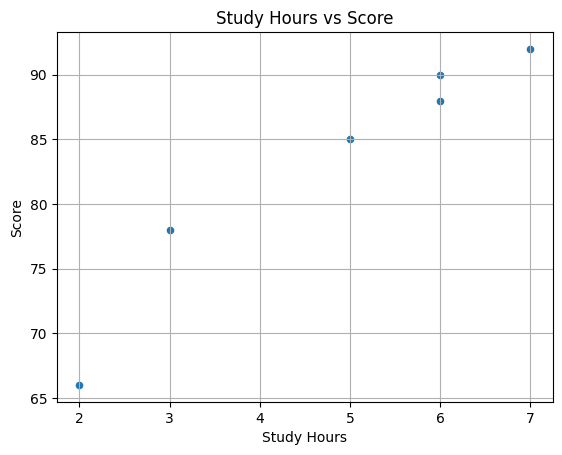

In [42]:
# Pandas 绘图底层使用 Matplotlib。
ax = df.plot.scatter(
    x="study_hours",
    y="score",
    title="Study Hours vs Score",
    grid=True,
)
ax.set_xlabel("Study Hours")
ax.set_ylabel("Score")

# 12. 文件读取与保存

## CSV 高频参数

```python
pd.read_csv(
    path,
    usecols=[...],       # 只读取需要的列
    dtype={...},         # 指定类型
    parse_dates=[...],   # 解析日期列
    na_values=[...],     # 指定哪些字符串视为缺失值
    encoding="utf-8",
)
```

保存 CSV 时通常写 `index=False`，否则会额外保存 DataFrame 索引。

In [43]:
output_dir = Path("pandas_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

csv_path = output_dir / "student_scores.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("CSV 已保存：", csv_path.resolve())

CSV 已保存： /mnt/data/pandas_outputs/student_scores.csv


In [44]:
df_loaded = pd.read_csv(
    csv_path,
    parse_dates=["exam_date"],
)

print(type(df_loaded))
print(df_loaded.dtypes)
df_loaded

<class 'pandas.core.frame.DataFrame'>
student_id              int64
name                   object
gender                 object
city                   object
score                   int64
study_hours             int64
exam_date      datetime64[ns]
dtype: object


,student_id,name,gender,city,score,study_hours,exam_date
0,1001,Tom,male,Dalian,85,5,2026-07-01
1,1002,Jerry,male,Shenyang,90,6,2026-07-01
2,1003,Alice,female,Dalian,78,3,2026-07-01
3,1004,Bob,male,Beijing,92,7,2026-07-02
4,1005,Mike,male,Shenyang,66,2,2026-07-02
5,1006,Lucy,female,Dalian,88,6,2026-07-02


## 其他常见格式

```python
# Excel（通常需要 openpyxl）
df.to_excel("data.xlsx", index=False)
df = pd.read_excel("data.xlsx", sheet_name=0)

# Parquet：体积通常更小、读取更快，并能较好保留类型
# 通常需要 pyarrow 或 fastparquet
df.to_parquet("data.parquet", index=False)
df = pd.read_parquet("data.parquet")

# 大型 CSV 可分块读取，避免一次性占满内存
for chunk in pd.read_csv("large.csv", chunksize=100_000):
    ...
```

# 13. 机器学习中的完整 Pandas 预处理流程

下面演示一个典型流程：

```text
定义 X/y → 划分训练/测试集 → 只用训练集计算填充值
→ 类别编码 → 对齐列 → 检查结果
```

> Pandas 适合探索和手工预处理。正式项目中，建议使用 scikit-learn 的 `Pipeline`、`ColumnTransformer`、`SimpleImputer`、`OneHotEncoder`，以减少数据泄漏和训练/预测不一致。

In [45]:
from sklearn.model_selection import train_test_split

ml_df = df[["gender", "city", "study_hours", "score"]].copy()

# 人为制造一个缺失值，演示完整流程。
ml_df.loc[2, "study_hours"] = np.nan

X = ml_df[["gender", "city", "study_hours"]].copy()
y = ml_df["score"].copy()  # 回归标签

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4, 3)
X_test shape: (2, 3)


In [46]:
# 1. 只使用训练集计算中位数。
train_hours_median = X_train["study_hours"].median()

# 2. 使用同一个训练集统计量填充训练集和测试集。
X_train = X_train.copy()
X_test = X_test.copy()
X_train["study_hours"] = X_train["study_hours"].fillna(train_hours_median)
X_test["study_hours"] = X_test["study_hours"].fillna(train_hours_median)

print("训练集计算出的中位数：", train_hours_median)

训练集计算出的中位数： 6.0


In [47]:
# 3. 训练集和测试集分别独热编码。
X_train_encoded = pd.get_dummies(
    X_train,
    columns=["gender", "city"],
    dummy_na=True,
    dtype="float32",
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=["gender", "city"],
    dummy_na=True,
    dtype="float32",
)

# 4. 测试集按训练集列重新对齐。
# 训练中未出现的测试类别会成为全 0；训练集存在但测试集没有的列会补 0。
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0,
)

print("训练集列：", X_train_encoded.columns.tolist())
print("列是否完全一致：", X_train_encoded.columns.equals(X_test_encoded.columns))
display(X_train_encoded)
display(X_test_encoded)

训练集列： ['study_hours', 'gender_female', 'gender_male', 'gender_nan', 'city_Beijing', 'city_Dalian', 'city_Shenyang', 'city_nan']
列是否完全一致： True


,study_hours,gender_female,gender_male,gender_nan,city_Beijing,city_Dalian,city_Shenyang,city_nan
5,6.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,6.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,7.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


,study_hours,gender_female,gender_male,gender_nan,city_Beijing,city_Dalian,city_Shenyang,city_nan
0,5.0,0,1.0,0.0,0,1.0,0.0,0.0
1,6.0,0,1.0,0.0,0,0.0,1.0,0.0


## 合并训练/测试特征后统一编码的写法

很多教学代码会先合并特征：

```python
all_features = pd.concat([train_features, test_features], axis=0)
all_features = pd.get_dummies(all_features, dummy_na=True)
```

然后根据训练集原始行数重新拆分：

```python
n_train = train_features.shape[0]
train_features = all_features.iloc[:n_train]
test_features = all_features.iloc[n_train:]
```

这种写法可以保证列完全一致，在离线竞赛中很常见。但正式生产流程更推荐“只在训练集拟合预处理器”，再用同一预处理器转换验证/测试数据。

In [48]:
train_feature_df = df.iloc[:4][["gender", "city", "study_hours"]].copy()
test_feature_df = df.iloc[4:][["gender", "city", "study_hours"]].copy()

n_train = train_feature_df.shape[0]
all_features = pd.concat([train_feature_df, test_feature_df], axis=0)
all_features = pd.get_dummies(all_features, dummy_na=True, dtype="float32")

train_part = all_features.iloc[:n_train]
test_part = all_features.iloc[n_train:]

print("all_features shape:", all_features.shape)
print("train_part shape:", train_part.shape)
print("test_part shape:", test_part.shape)

all_features shape: (6, 8)
train_part shape: (4, 8)
test_part shape: (2, 8)


# 14. DataFrame → NumPy → PyTorch Tensor

`pd.read_csv()` 返回 `DataFrame`。模型训练通常需要 NumPy 数组或 Tensor：

```text
DataFrame → .to_numpy() → ndarray → torch.from_numpy() → Tensor
```

关键点：

1. Tensor 只能保存统一的数值类型，字符串列必须先删除或编码。
2. 推荐 `.to_numpy()`，比旧式 `.values` 意图更明确。
3. 特征通常使用 `float32`。
4. 回归标签通常使用 `float32`；多分类标签通常使用 `int64/torch.long`。

In [49]:
# DataFrame → NumPy
X_train_numpy = X_train_encoded.to_numpy(dtype=np.float32)
y_train_numpy = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)

print(type(X_train_numpy), X_train_numpy.dtype, X_train_numpy.shape)
print(type(y_train_numpy), y_train_numpy.dtype, y_train_numpy.shape)

<class 'numpy.ndarray'> float32 (4, 8)
<class 'numpy.ndarray'> float32 (4, 1)


In [50]:
import torch

# NumPy → Tensor。torch.from_numpy 通常与 NumPy 数组共享底层内存。
X_train_tensor = torch.from_numpy(X_train_numpy)
y_train_tensor = torch.from_numpy(y_train_numpy)

print(type(X_train_tensor), X_train_tensor.dtype, X_train_tensor.shape)
print(type(y_train_tensor), y_train_tensor.dtype, y_train_tensor.shape)

<class 'torch.Tensor'> torch.float32 torch.Size([4, 8])
<class 'torch.Tensor'> torch.float32 torch.Size([4, 1])


In [51]:
# 多分类/二分类标签通常使用 int64，也就是 torch.long。
# 这里把“分数是否至少为 85”作为示例分类标签。
y_class_numpy = (df["score"] >= 85).to_numpy(dtype=np.int64)
y_class_tensor = torch.from_numpy(y_class_numpy)

print(y_class_tensor)
print(y_class_tensor.dtype)

tensor([1, 1, 0, 1, 0, 1])
torch.int64


## 为什么不直接 `torch.tensor(df)`？

DataFrame 可能包含字符串、日期、混合类型和索引。更稳定的写法是：

```python
array = df_numeric.to_numpy(dtype="float32")
tensor = torch.from_numpy(array)
```

若使用：

```python
torch.tensor(df.to_numpy())
```

通常还会复制数据；而 `torch.from_numpy()` 通常共享内存，效率更高。

In [52]:
# TensorDataset / DataLoader：进入 PyTorch 训练前的常见下一步。
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

batch_features, batch_labels = next(iter(train_loader))
print("batch_features shape:", batch_features.shape)
print("batch_labels shape:", batch_labels.shape)

batch_features shape: torch.Size([2, 8])
batch_labels shape: torch.Size([2, 1])


# 15. 方法链与实用高级用法

方法链可以把数据处理步骤按顺序写在一起，减少大量临时变量。但链条过长时应拆分，保证可读性。

In [53]:
clean_summary = (
    df.copy()
      .assign(
          passed=lambda x: x["score"] >= 60,
          score_per_hour=lambda x: x["score"] / x["study_hours"],
      )
      .query("study_hours >= 3")
      .sort_values("score", ascending=False)
      .loc[:, ["name", "gender", "score", "study_hours", "score_per_hour", "passed"]]
      .reset_index(drop=True)
)

clean_summary

,name,gender,score,study_hours,score_per_hour,passed
0,Bob,male,92,7,13.142857,True
1,Jerry,male,90,6,15.000000,True
2,Lucy,female,88,6,14.666667,True
3,Tom,male,85,5,17.000000,True
4,Alice,female,78,3,26.000000,True


## 内存与性能检查

大型数据中可使用：

```python
df.memory_usage(deep=True)
df["category_column"] = df["category_column"].astype("category")
```

避免对每一行写 Python 循环，优先使用向量化、`groupby`、`merge` 等 Pandas 操作。

In [54]:
memory_info = df.memory_usage(deep=True).sort_values(ascending=False)
memory_info

city           335
gender         322
name           318
Index          132
student_id      48
score           48
study_hours     48
exam_date       48
dtype: int64

# 16. 常见错误与注意事项

## 1. 链式赋值

不推荐：

```python
df[df["score"] > 80]["level"] = "high"
```

推荐：

```python
df.loc[df["score"] > 80, "level"] = "high"
```

## 2. `loc` 与 `iloc` 混淆

```python
df.loc[3]      # 标签为 3 的行
df.iloc[3]     # 位置为 3，即第 4 行
```

## 3. `Series` 与 `DataFrame` 形状混淆

```python
df["score"]     # Series，(n,)
df[["score"]]   # DataFrame，(n, 1)
```

## 4. 索引自动对齐

Pandas 在赋值、加减和 `concat(axis=1)` 时会按照索引标签自动对齐，而不是只看所在位置。必要时先 `reset_index(drop=True)`。

## 5. 字符串不能直接进入 Tensor

必须先删除、映射或独热编码。

## 6. 训练集与测试集编码后列不一致

使用训练集列对测试集 `reindex`，或使用 scikit-learn 的 `OneHotEncoder(handle_unknown="ignore")`。

## 7. 数据泄漏

均值、中位数、标准差、编码器等统计量只能在训练集上拟合。

## 8. 忘记 `index=False`

保存 CSV 时通常使用：

```python
df.to_csv(path, index=False)
```

## 9. `inplace=True`

它并不一定更快，也会让调试和方法链变得困难。通常更推荐显式重新赋值：

```python
df = df.drop(columns=[...])
```

# 17. Pandas 机器学习速查表

| 任务 | 常见写法 |
|---|---|
| 读取 CSV | `pd.read_csv(path)` |
| 保存 CSV | `df.to_csv(path, index=False)` |
| 前几行 | `df.head()` |
| 行列数 | `df.shape` |
| 数据类型 | `df.dtypes` / `df.info()` |
| 描述统计 | `df.describe()` |
| 选一列 | `df["col"]` |
| 选多列 | `df[["a", "b"]]` |
| 按标签选择 | `df.loc[rows, cols]` |
| 按位置选择 | `df.iloc[rows, cols]` |
| 条件筛选 | `df[df["score"] >= 80]` |
| 多条件 | `df[(cond1) & (cond2)]` |
| 排序 | `df.sort_values("score", ascending=False)` |
| 新增列 | `df["new"] = ...` |
| 条件修改 | `df.loc[cond, "col"] = value` |
| 删除列 | `df.drop(columns=[...])` |
| 重命名 | `df.rename(columns={...})` |
| 缺失统计 | `df.isna().sum()` |
| 填充缺失 | `df["x"].fillna(value)` |
| 删除缺失 | `df.dropna(subset=[...])` |
| 重复检查 | `df.duplicated().sum()` |
| 删除重复 | `df.drop_duplicates()` |
| 类型转换 | `astype()` / `pd.to_numeric()` |
| 日期转换 | `pd.to_datetime()` |
| 字符串处理 | `df["text"].str...` |
| 类别映射 | `df["gender"].map({...})` |
| 独热编码 | `pd.get_dummies(df, columns=[...])` |
| 类别频数 | `value_counts()` |
| 分组统计 | `df.groupby(...).agg(...)` |
| 连接表 | `df1.merge(df2, on=..., how=...)` |
| 拼接表 | `pd.concat([...], axis=0/1)` |
| 相关系数 | `df[numeric_cols].corr()` |
| 转 NumPy | `df.to_numpy(dtype="float32")` |
| 转 Tensor | `torch.from_numpy(array)` |

# 18. 综合练习

建议先独立完成，再展开答案。

1. 选择 `name`、`score`、`study_hours` 三列。
2. 筛选分数至少 85 且学习时间至少 5 小时的学生。
3. 按分数降序排列，取前 3 名。
4. 新增 `passed` 列，规则为分数至少 60。
5. 计算不同性别的平均分、最高分和人数。
6. 将 `gender`、`city` 独热编码。
7. 将数值特征转为 `float32` NumPy 数组和 Tensor。

In [55]:
# 在这里练习。可以删除 pass 后填写代码。
pass

<details>
<summary><strong>点击展开参考答案</strong></summary>

```python
# 1
selected = df[["name", "score", "study_hours"]]

# 2
filtered = df[(df["score"] >= 85) & (df["study_hours"] >= 5)]

# 3
top3 = df.sort_values("score", ascending=False).head(3)

# 4
df_answer = df.copy()
df_answer["passed"] = df_answer["score"] >= 60

# 5
stats = (
    df.groupby("gender")
      .agg(
          mean_score=("score", "mean"),
          max_score=("score", "max"),
          count=("student_id", "count"),
      )
)

# 6
encoded = pd.get_dummies(
    df[["gender", "city", "score", "study_hours"]],
    columns=["gender", "city"],
    dtype="float32",
)

# 7
array = encoded.to_numpy(dtype=np.float32)
tensor = torch.from_numpy(array)
```
</details>

# 最后总结

机器学习中最重要的 Pandas 能力不是记住所有 API，而是能稳定完成下面几件事：

1. 看懂数据的行、列、类型和缺失情况。
2. 正确选择、筛选、修改和合并数据。
3. 把字符串、缺失值和日期处理成模型可用的特征。
4. 严格区分训练集、验证集、测试集，避免数据泄漏。
5. 把最终数值特征转换成 NumPy 或 Tensor，并检查 `shape` 和 `dtype`。

遇到问题时，优先检查：

```python
print(type(data))
print(data.shape)
print(data.dtypes)
print(data.isna().sum())
print(data.head())
```